<a href="https://colab.research.google.com/github/NataCode13/Challenge-1-Python/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Introducción

En este proyecto se realiza un análisis exploratorio de datos de cuatro tiendas con el objetivo de ayudar al señor Juan a tomar una decisión: identificar cuál tienda conviene vender para invertir en un nuevo negocio.

Para ello se analizan indicadores como el ingreso total por tienda, la cantidad de ventas por categoría, la calificación promedio de clientes, los productos más y menos vendidos y el costo de envío promedio.

Además se generan visualizaciones para resumir los principales hallazgos.

### Importación de datos



In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


PARA REVISIÓN Y LIMPIEZA DE DATOS:

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display

tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4,
}

for nombre, df in tiendas.items():
    df["Fecha de Compra"] = pd.to_datetime(df["Fecha de Compra"], dayfirst=True)
    print(f"{nombre}: {df.shape[0]} filas y {df.shape[1]} columnas")
    print(f"Nulos: {df.isnull().sum().sum()} | Duplicados: {df.duplicated().sum()}")
    print("-" * 50)

tienda.head()

Tienda 1: 2359 filas y 12 columnas
Nulos: 0 | Duplicados: 0
--------------------------------------------------
Tienda 2: 2359 filas y 12 columnas
Nulos: 0 | Duplicados: 0
--------------------------------------------------
Tienda 3: 2359 filas y 12 columnas
Nulos: 0 | Duplicados: 0
--------------------------------------------------
Tienda 4: 2358 filas y 12 columnas
Nulos: 0 | Duplicados: 0
--------------------------------------------------


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,2021-01-16,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,2022-05-18,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,2021-03-15,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,2022-05-03,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,2020-11-07,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [6]:
facturacion = pd.DataFrame({
    "Tienda": list(tiendas.keys()),
    "Ingreso total": [df["Precio"].sum() for df in tiendas.values()],
    "Cantidad ventas": [len(df) for df in tiendas.values()],
})

facturacion = facturacion.sort_values(by="Ingreso total", ascending=False)
facturacion

,Tienda,Ingreso total,Cantidad ventas
0,Tienda 1,1.150880e+09,2359
1,Tienda 2,1.116344e+09,2359
2,Tienda 3,1.098020e+09,2359
3,Tienda 4,1.038376e+09,2358


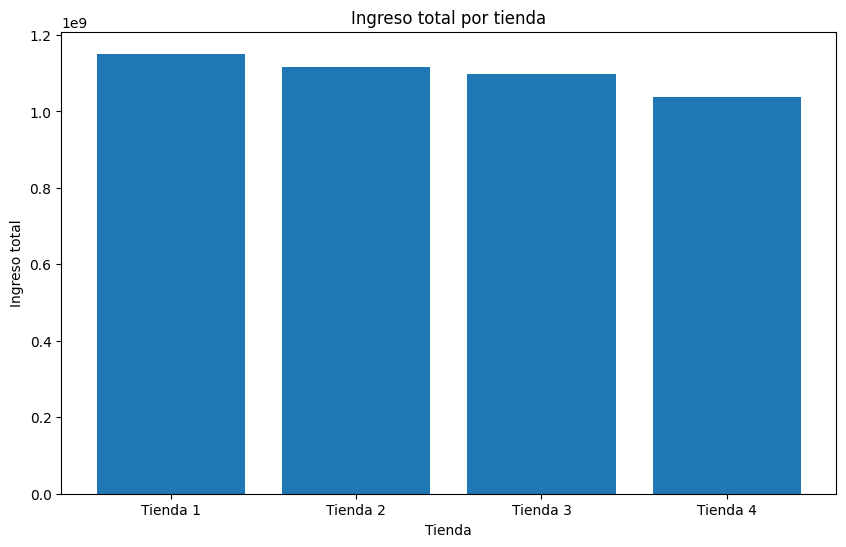

La tienda con mayor facturación es: Tienda 1
La tienda con menor facturación es: Tienda 4


In [7]:
plt.figure(figsize=(10, 6))
plt.bar(facturacion["Tienda"], facturacion["Ingreso total"])
plt.title("Ingreso total por tienda")
plt.xlabel("Tienda")
plt.ylabel("Ingreso total")
plt.show()

print("La tienda con mayor facturación es:", facturacion.iloc[0, 0])
print("La tienda con menor facturación es:", facturacion.iloc[-1, 0])

# 2. Ventas por categoría

In [8]:
ventas_categoria = {}

for nombre, df in tiendas.items():
    ventas_categoria[nombre] = df["Categoría del Producto"].value_counts()
    print(f"\n{nombre}")
    display(ventas_categoria[nombre].to_frame("Cantidad de ventas"))


Tienda 1


,Cantidad de ventas
Categoría del Producto,
Muebles,465
Electrónicos,448
Juguetes,324
Electrodomésticos,312
Deportes y diversión,284
Instrumentos musicales,182
Libros,173
Artículos para el hogar,171



Tienda 2


,Cantidad de ventas
Categoría del Producto,
Muebles,442
Electrónicos,422
Juguetes,313
Electrodomésticos,305
Deportes y diversión,275
Instrumentos musicales,224
Libros,197
Artículos para el hogar,181



Tienda 3


,Cantidad de ventas
Categoría del Producto,
Muebles,499
Electrónicos,451
Juguetes,315
Electrodomésticos,278
Deportes y diversión,277
Libros,185
Instrumentos musicales,177
Artículos para el hogar,177



Tienda 4


,Cantidad de ventas
Categoría del Producto,
Muebles,480
Electrónicos,451
Juguetes,338
Deportes y diversión,277
Electrodomésticos,254
Artículos para el hogar,201
Libros,187
Instrumentos musicales,170


,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Categoría del Producto,,,,
Artículos para el hogar,171,181,177,201
Deportes y diversión,284,275,277,277
Electrodomésticos,312,305,278,254
Electrónicos,448,422,451,451
Instrumentos musicales,182,224,177,170
Juguetes,324,313,315,338
Libros,173,197,185,187
Muebles,465,442,499,480


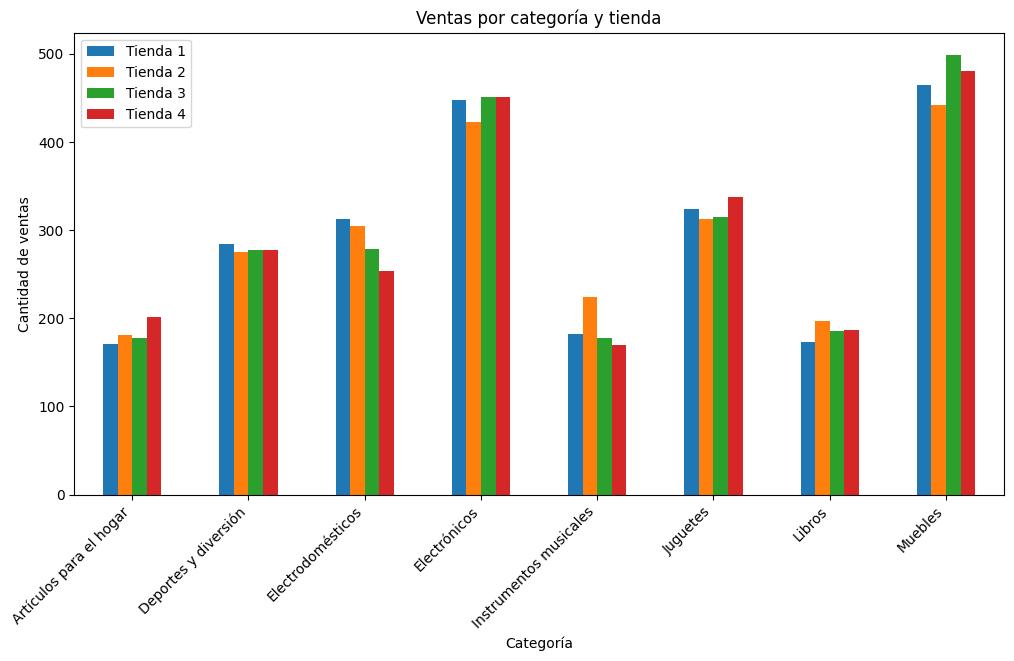

In [9]:
categoria_total = pd.DataFrame(ventas_categoria).fillna(0).astype(int)
display(categoria_total)

categoria_total.plot(kind="bar", figsize=(12, 6))
plt.title("Ventas por categoría y tienda")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de ventas")
plt.xticks(rotation=45, ha="right")
plt.show()

# 3. Calificación promedio de la tienda


In [10]:
calificaciones = pd.DataFrame({
    "Tienda": list(tiendas.keys()),
    "Calificación promedio": [df["Calificación"].mean() for df in tiendas.values()]
}).sort_values(by="Calificación promedio", ascending=False)

calificaciones

,Tienda,Calificación promedio
2,Tienda 3,4.048326
1,Tienda 2,4.037304
3,Tienda 4,3.995759
0,Tienda 1,3.976685


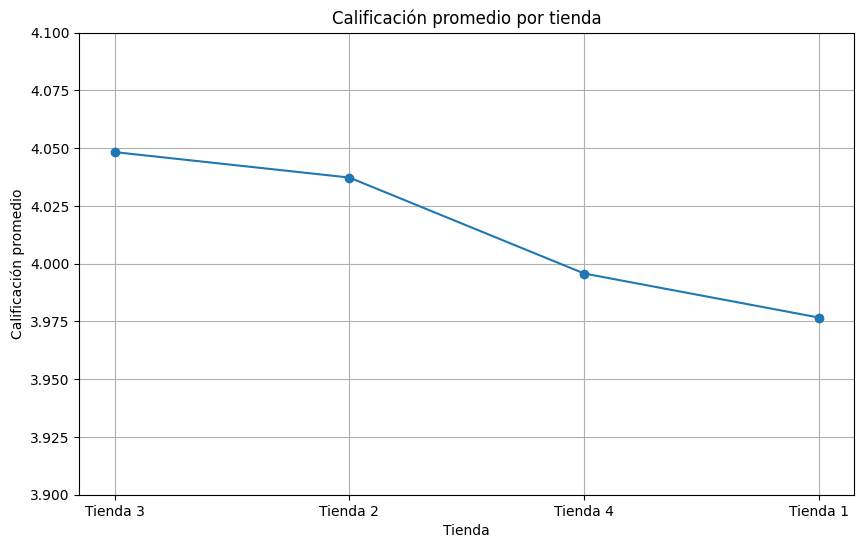

La tienda mejor evaluada es: Tienda 3
La tienda peor evaluada es: Tienda 1


In [11]:
plt.figure(figsize=(10, 6))
plt.plot(calificaciones["Tienda"], calificaciones["Calificación promedio"], marker="o")
plt.title("Calificación promedio por tienda")
plt.xlabel("Tienda")
plt.ylabel("Calificación promedio")
plt.ylim(3.9, 4.1)
plt.grid(True)
plt.show()

print("La tienda mejor evaluada es:", calificaciones.iloc[0, 0])
print("La tienda peor evaluada es:", calificaciones.iloc[-1, 0])

# 4. Productos más y menos vendidos

In [12]:
for nombre, df in tiendas.items():
    conteo_productos = df["Producto"].value_counts()
    print(f"\n{nombre} - 5 productos más vendidos")
    display(conteo_productos.head(5).to_frame("Cantidad"))
    print(f"{nombre} - 5 productos menos vendidos")
    display(conteo_productos.sort_values().head(5).to_frame("Cantidad"))


Tienda 1 - 5 productos más vendidos


,Cantidad
Producto,
Microondas,60
TV LED UHD 4K,60
Armario,60
Secadora de ropa,58
Mesa de noche,56


Tienda 1 - 5 productos menos vendidos


,Cantidad
Producto,
Auriculares con micrófono,33
Celular ABXY,33
Olla de presión,35
Pandereta,36
Mochila,39



Tienda 2 - 5 productos más vendidos


...

,Cantidad
Producto,
Bloques de construcción,35
Microondas,36
Set de vasos,36
Mochila,36
Vaso térmico,38



Tienda 4 - 5 productos más vendidos


,Cantidad
Producto,
Cama box,62
Cubertería,59
Dashboards con Power BI,56
Cama king,56
Carrito de control remoto,55


Tienda 4 - 5 productos menos vendidos


,Cantidad
Producto,
Guitarra eléctrica,33
Armario,34
Guitarra acústica,37
Ciencia de datos con Python,38
Lavadora de ropa,38


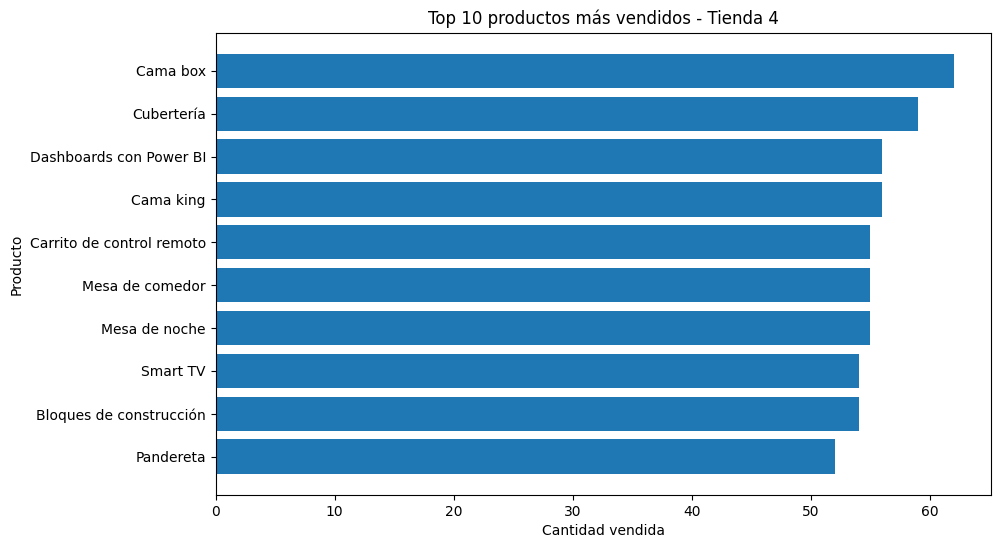

In [13]:
top_productos_t4 = tiendas["Tienda 4"]["Producto"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_productos_t4.index[::-1], top_productos_t4.values[::-1])
plt.title("Top 10 productos más vendidos - Tienda 4")
plt.xlabel("Cantidad vendida")
plt.ylabel("Producto")
plt.show()

# 5. Envío promedio por tienda

In [14]:
envio_promedio = pd.DataFrame({
    "Tienda": list(tiendas.keys()),
    "Costo de envío promedio": [df["Costo de envío"].mean() for df in tiendas.values()],
    "Calificación promedio": [df["Calificación"].mean() for df in tiendas.values()],
    "Ingreso total": [df["Precio"].sum() for df in tiendas.values()],
})

envio_promedio.sort_values(by="Costo de envío promedio")

,Tienda,Costo de envío promedio,Calificación promedio,Ingreso total
3,Tienda 4,23459.457167,3.995759,1.038376e+09
2,Tienda 3,24805.680373,4.048326,1.098020e+09
1,Tienda 2,25216.235693,4.037304,1.116344e+09
0,Tienda 1,26018.609580,3.976685,1.150880e+09


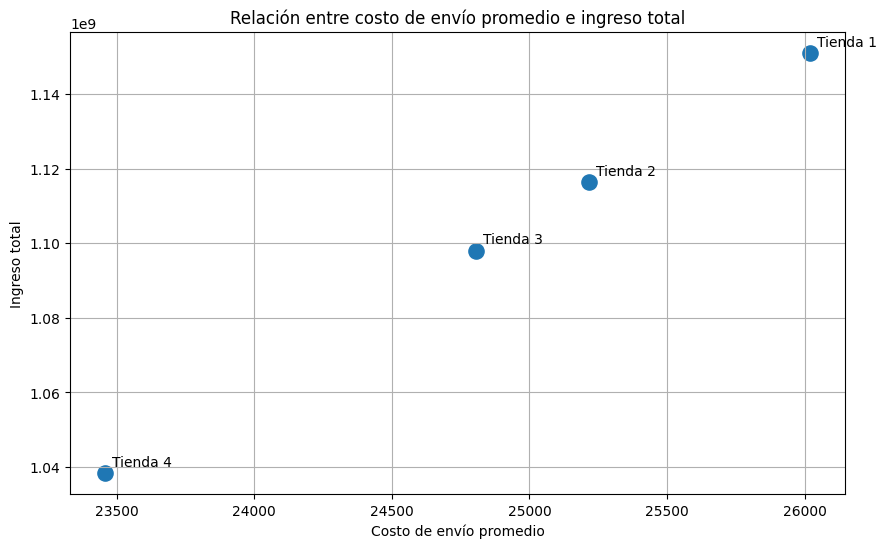

,Tienda,Costo de envío promedio,Calificación promedio,Ingreso total
0,Tienda 1,26018.609580,3.976685,1.150880e+09
1,Tienda 2,25216.235693,4.037304,1.116344e+09
2,Tienda 3,24805.680373,4.048326,1.098020e+09
3,Tienda 4,23459.457167,3.995759,1.038376e+09


In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(envio_promedio["Costo de envío promedio"], envio_promedio["Ingreso total"], s=120)

for _, fila in envio_promedio.iterrows():
    plt.annotate(fila["Tienda"], (fila["Costo de envío promedio"], fila["Ingreso total"]),
                 xytext=(5,5), textcoords="offset points")

plt.title("Relación entre costo de envío promedio e ingreso total")
plt.xlabel("Costo de envío promedio")
plt.ylabel("Ingreso total")
plt.grid(True)
plt.show()

envio_promedio

###CONCLUSIÓN

## En resumen:
- **Tienda 1**: lidera en ingresos, pero tiene la peor calificación promedio y el costo de envío más alto.
- **Tienda 2**: buen nivel entre ingresos y satisfacción del cliente.
- **Tienda 3**: presenta la mejor calificación promedio y un buen nivel de ingresos.
- **Tienda 4**: muestra el desempeño más débil en facturación general.

Por lo que, después de comparar los principales indicadores de desempeño, la recomendación es vender la **Tienda 4**.

##Justificación:
- Fue la tienda con **menor ingreso total** entre las cuatro.
- También tuvo **la menor cantidad de ventas** del conjunto analizado.
- Su **calificación promedio** no fue la peor, pero tampoco destacó frente a la Tienda 2 y Tienda 3.
- Su principal punto positivo fue tener el **menor costo de envío promedio**, pero eso no es suficiente para compensar su nivel de ingresos.